# Data Generation - 50,000 Synthetic COD Orders

**Razorpay AI Buildathon 2026 - Track 02: AI Risk Manager**

Return-Risk Scorer for COD orders (Return-to-Origin prediction).

---

### What this notebook does

Builds 50,000 synthetic orders on a **real geographic skeleton** - the India Post
pincode directory - and calibrates the RTO labels against **published Indian
statistics**, enforced by assertion rather than by inspection.

### What it does not claim

There is no public dataset of Indian COD orders with RTO outcomes. Nothing here is
validated on real merchant data and no such claim is made. What is real is the
geography and the calibration target; see `DATA_CARD.md`.

### Three properties this notebook has to guarantee

| Property | Why | Enforced by |
|---|---|---|
| Reproducible | Two runs must be byte-identical | Single seeded RNG + SHA-256 manifest, re-run check in section 10 |
| Calibrated | Otherwise every downstream metric is fiction | Hard `assert` in section 7, mirrored in `tests/test_calibration.py` |
| Non-trivial | A separable toy problem proves nothing | Bernoulli draws from an overlapping probability field + irreducible logit noise |

## 1. Setup & seeded RNG

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from faker import Faker

# Repo root on the path so `src` is importable from a notebook kernel.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import src.generate as gen
from src.features import add_engineered_features

SEED = gen.SEED

for d in ["data/raw", "data/interim", "data/processed",
          "reports/figures", "reports/results"]:
    (ROOT / d).mkdir(parents=True, exist_ok=True)

print(f"python  {sys.version.split()[0]}")
print(f"numpy   {np.__version__}")
print(f"pandas  {pd.__version__}")
print(f"seed    {SEED}")
print(f"root    {ROOT}")

python  3.13.12
numpy   2.1.3
pandas  2.2.3
seed    20260101
root    D:\M.TECH\SEM-3\Razor pay


In [2]:
# ONE generator drives everything that determines a label. Faker is seeded from
# the same value but only ever produces cosmetic strings (names, phones, streets).
rng = np.random.default_rng(SEED)
Faker.seed(SEED)
faker = Faker("en_IN")
faker.seed_instance(SEED)

print("RNG and Faker seeded. Draw order below is fixed; do not reorder cells.")

RNG and Faker seeded. Draw order below is fixed; do not reorder cells.


## 2. Load real India Post pincode skeleton

In [3]:
skeleton = gen.load_pincode_skeleton(ROOT / "data/external/india_pincodes.csv")

print(f"post office rows -> {len(skeleton):,} unique pincodes")
print(f"districts        -> {skeleton['district'].nunique():,}")
print(f"states / UTs     -> {skeleton['state'].nunique():,}")
skeleton.head()

post office rows -> 23,899 unique pincodes
districts        -> 566
states / UTs     -> 35


,pincode,city,district,state,n_post_offices,tier
0,110001,New Delhi,New Delhi,Delhi,19,metro
1,110002,New Delhi,Central Delhi,Delhi,10,metro
2,110003,New Delhi,North Delhi,Delhi,13,metro
3,110004,New Delhi,Central Delhi,Delhi,1,metro
4,110005,New Delhi,Central Delhi,Delhi,9,metro


In [4]:
# Tier assignment is a rule, not a claim. Curated metro / tier-1 city lists,
# then district-headquarters towns as tier-2, everything else tier-3.
# Post-office density is deliberately NOT used: in the India Post directory it
# tracks rural spread, not urbanisation (Thrissur has 370 pincodes, Pune 125).
tier_counts = skeleton["tier"].value_counts().reindex(gen.TIER_ORDER)
display(
    pd.DataFrame({
        "pincodes": tier_counts,
        "share": (tier_counts / len(skeleton)).round(4),
        "order_volume_weight": pd.Series(gen.TIER_VOLUME_WEIGHT),
        "courier_eta_days": pd.Series(gen.TIER_ETA_DAYS),
    })
)

,pincodes,share,order_volume_weight,courier_eta_days
metro,752,0.0315,0.34,2.0
tier_1,2895,0.1211,0.30,3.0
tier_2,14848,0.6213,0.22,4.5
tier_3,5404,0.2261,0.14,6.5


## 3. Grounding constants from published Indian RTO statistics

In [5]:
evidence = gen.load_evidence(ROOT / "config/evidence.yaml")

rows = []
def _walk(node, path=""):
    if isinstance(node, dict) and "value" in node:
        rows.append({
            "constant": path,
            "value": node["value"],
            "status": node.get("status", "grounded"),
            "source": str(node.get("source", node.get("note", "")))[:78],
        })
    elif isinstance(node, dict):
        for k, v in node.items():
            _walk(v, f"{path}.{k}" if path else k)

_walk(evidence)
evidence_table = pd.DataFrame(rows)
display(evidence_table.style.hide(axis="index"))

constant,value,status,source
cod_share,0.620000,grounded,Industry reports: 60-65% of Indian e-commerce orders are COD
cod_rto_rate,0.260000,grounded,Shipway ShipNotes FY25 - 26% RTO on COD/non-prepaid orders
prepaid_rto_rate,0.020000,grounded,Shipway ShipNotes FY25 - <2% RTO on prepaid orders
order_value_bands.under_500,0.250000,grounded,ShipNotes FY25 category/value breakdown
order_value_bands.mid_500_1000,0.280000,grounded,ShipNotes FY25 - the 'impulse zone'
order_value_bands.over_1000,0.240000,grounded,ShipNotes FY25 - more considered purchases
city_rto_range.min,0.180000,grounded,ShipNotes FY25 city-wise
city_rto_range.max,0.350000,grounded,ShipNotes FY25 city-wise
fashion_rto_rate,0.400000,grounded,Fashion/apparel RTO reported 40%+ on COD; calibrated as an explicit cell
category_multipliers.fashion,1.550000,grounded,Fashion/apparel RTO reported 40%+


In [6]:
# The three targets that section 7 will assert against.
print("COD RTO rate     ", evidence["cod_rto_rate"]["value"], "  <- ShipNotes FY25")
print("Prepaid RTO rate <", evidence["prepaid_rto_rate"]["value"], "  <- ShipNotes FY25")
print("Order-value curve ", {k: v["value"] for k, v in evidence["order_value_bands"].items()})
print()
print("NOTE the curve is NON-MONOTONIC: it peaks in the Rs500-1000 impulse band")
print("and FALLS above Rs1,000. Assuming RTO rises with order value is the")
print("common mistake, and the published data contradicts it.")

COD RTO rate      0.26   <- ShipNotes FY25
Prepaid RTO rate < 0.02   <- ShipNotes FY25
Order-value curve  {'under_500': 0.25, 'mid_500_1000': 0.28, 'over_1000': 0.24}

NOTE the curve is NON-MONOTONIC: it peaks in the Rs500-1000 impulse band
and FALLS above Rs1,000. Assuming RTO rises with order value is the
common mistake, and the published data contradicts it.


## 4. Build customer population (persistent identity & history)

In [7]:
priors = gen.assign_pincode_priors(skeleton, evidence, rng)

lo = evidence["city_rto_range"]["min"]["value"]
hi = evidence["city_rto_range"]["max"]["value"]
print(f"published city range: {lo:.0%} ({evidence['city_rto_range']['min']['city']})"
      f" -> {hi:.0%} ({evidence['city_rto_range']['max']['city']})")
print(f"assigned pincode priors: {priors['pincode_rto_prior'].min():.3f}"
      f" -> {priors['pincode_rto_prior'].max():.3f}")

display(
    priors.groupby("tier")["city_rto_prior"]
    .agg(["mean", "min", "max", "size"])
    .reindex(gen.TIER_ORDER).round(4)
)
# The two cities named in evidence.yaml are pinned, not sampled.
display(priors[priors["city"].isin(["Vadodara", "Patna"])]
        .groupby("city")["city_rto_prior"].first().round(4))

published city range: 18% (Vadodara) -> 35% (Patna)
assigned pincode priors: 0.180 -> 0.350


,mean,min,max,size
tier,,,,
metro,0.2499,0.2281,0.2845,752
tier_1,0.2560,0.1800,0.3500,2895
tier_2,0.2854,0.2221,0.3335,14848
tier_3,0.3174,0.2351,0.3490,5404


city
Patna       0.35
Vadodara    0.18
Name: city_rto_prior, dtype: float64

In [8]:
# A real merchant ships to a footprint, not to all 23,916 pincodes uniformly.
footprint = gen.sample_serviced_pincodes(priors, rng)
print(f"serviced pincodes: {len(footprint):,}")
display(footprint.groupby("tier")["volume_weight"].agg(["size", "sum"])
        .reindex(gen.TIER_ORDER).round(4))

serviced pincodes: 3,062


,size,sum
tier,,
metro,752,0.2976
tier_1,1050,0.4004
tier_2,770,0.2096
tier_3,490,0.0925


In [9]:
customers = gen.build_customers(footprint, rng, faker, n_customers=gen.N_CUSTOMERS)

print(f"customers: {len(customers):,}")
print()
print("Two latents drive labels and are NEVER features:")
print("  reliability_z    - propensity to actually take delivery")
print("  address_quality  - the truth about the address; the model sees only")
print("                     the rendered string, so its address features are a")
print("                     noisy read of this latent, not a copy of it.")
display(customers[["customer_id", "home_city", "home_tier", "address_line"]].head(6))

customers: 20,000

Two latents drive labels and are NEVER features:
  reliability_z    - propensity to actually take delivery
  address_quality  - the truth about the address; the model sees only
                     the rendered string, so its address features are a
                     noisy read of this latent, not a copy of it.


,customer_id,home_city,home_tier,address_line
0,CUST000000,Mahboobnagar,tier_2,"H No 17, Mane Chowk, Near Shiv Mandir, Mahboob..."
1,CUST000001,New Delhi,metro,"H No 26/24, Hayer Ganj, Near Post Office, New ..."
2,CUST000002,Kishanganj,tier_2,"Gala Circle, Kishanganj"
3,CUST000003,Sivaganga,tier_2,"H No 88/846, Sur Zila, Sivaganga West, Sivaganga"
4,CUST000004,Mangalore,tier_1,"H No H.No. 730, gali no 4, Near Post Office, M..."
5,CUST000005,Pune,metro,"H No 80, Sule Path, Near SBI Bank, Pune Colony..."


In [10]:
# Address strings degrade with the latent. Sanity-check that the rendering
# actually varies - if every address looked the same the feature would be dead.
sample = customers.assign(q_bucket=pd.qcut(customers["address_quality"], 4,
                                           labels=["worst", "low", "high", "best"]))
for b in ["worst", "best"]:
    print(f"--- address_quality: {b} ---")
    for a in sample.loc[sample.q_bucket == b, "address_line"].head(3):
        print("   ", a)
    print()

--- address_quality: worst ---
    Gala Circle, Kishanganj
    H No 88/846, Sur Zila, Sivaganga West, Sivaganga
    H No 12/265, bazar, Mangalore Nagar, Mangalore

--- address_quality: best ---
    H No 26/24, Hayer Ganj, Near Post Office, New Delhi East, New Delhi
    H No 80, Sule Path, Near SBI Bank, Pune Colony, Pune
    H No 101, Anand Path, Near Water Tank, Coimbatore Puram, Coimbatore



## 5. Generate 50,000 orders

In [11]:
orders, cod_logit_raw = gen.generate_orders(
    customers, footprint, rng, faker, n_orders=gen.N_ORDERS
)
orders = gen._finalise_payment_mode(orders, cod_logit_raw, evidence, rng)

# Attach the customer-level fields the order log would carry.
cust_by_id = customers.set_index("customer_id")
orders["_reliability_z"] = orders["customer_id"].map(cust_by_id["reliability_z"])
orders["customer_name"] = orders["customer_id"].map(cust_by_id["customer_name"])
orders["phone"] = orders["customer_id"].map(cust_by_id["phone"])

print(f"orders: {len(orders):,}")
print(f"window: {orders['order_ts'].min():%Y-%m-%d} -> {orders['order_ts'].max():%Y-%m-%d}")
print(f"COD share: {orders['is_cod'].mean():.1%}"
      f"  (published {evidence['cod_share']['value']:.0%})")

orders: 50,000
window: 2024-01-01 -> 2025-06-30
COD share: 61.8%  (published 62%)


In [12]:
# Checkout-time features that are ALSO label drivers, so they must exist before
# labels are drawn. order_velocity_24h counts strictly earlier orders only.
orders = gen.add_checkout_features(orders, customers, rng)

display(orders[["order_id", "order_ts", "customer_id", "city", "pincode_tier",
                "category", "order_value", "order_value_band", "payment_mode",
                "discount_pct", "delivery_days_est", "order_velocity_24h",
                "account_age_days"]].head(8))

,order_id,order_ts,customer_id,city,pincode_tier,category,order_value,order_value_band,payment_mode,discount_pct,delivery_days_est,order_velocity_24h,account_age_days
0,ORD000000,2024-01-01 10:23:40.346132186,CUST010422,Pune,metro,home_kitchen,1657.0,1000_plus,PREPAID,0.155,3.7,0,102.43
1,ORD000001,2024-01-01 11:13:43.171313827,CUST001599,Pune,metro,accessories,1351.0,1000_plus,COD,0.134,2.2,0,44.47
2,ORD000002,2024-01-01 12:47:09.518135117,CUST006797,Ranchi,tier_1,accessories,189.0,under_500,COD,0.259,3.7,0,1.53
3,ORD000003,2024-01-01 13:41:32.281843979,CUST013642,New Delhi,metro,fashion,769.0,500_1000,PREPAID,0.143,4.0,0,1.57
4,ORD000004,2024-01-01 14:28:26.047731700,CUST005550,Chennai,metro,fashion,1795.0,1000_plus,PREPAID,0.152,2.4,0,32.60
5,ORD000005,2024-01-01 15:02:16.750962867,CUST017562,Salem,tier_1,home_kitchen,1704.0,1000_plus,COD,0.151,4.4,0,139.63
6,ORD000006,2024-01-01 15:42:26.489548863,CUST007892,Bangalore,metro,fashion,1241.0,1000_plus,PREPAID,0.276,2.9,0,56.65
7,ORD000007,2024-01-01 15:46:14.480263684,CUST006926,Mumbai,metro,fashion,786.0,500_1000,COD,0.081,2.2,0,175.66


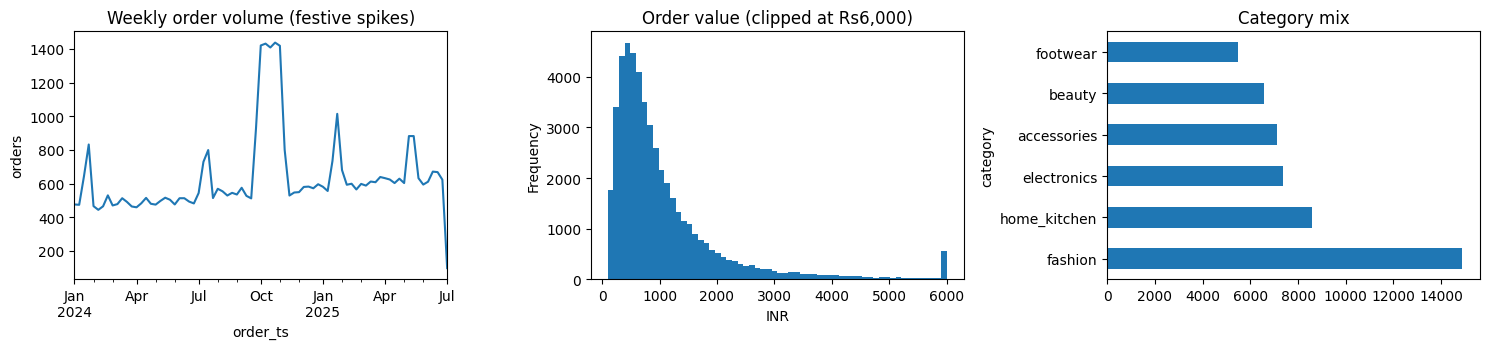

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
orders.set_index("order_ts").resample("W").size().plot(ax=ax[0])
ax[0].set_title("Weekly order volume (festive spikes)")
ax[0].set_ylabel("orders")
orders["order_value"].clip(upper=6000).plot(kind="hist", bins=60, ax=ax[1])
ax[1].set_title("Order value (clipped at Rs6,000)")
ax[1].set_xlabel("INR")
orders["category"].value_counts().plot(kind="barh", ax=ax[2])
ax[2].set_title("Category mix")
plt.tight_layout()
plt.savefig(ROOT / "reports/figures/01_order_stream.png", dpi=140, bbox_inches="tight")
plt.show()

## 6. Assign RTO labels from grounded drivers

In [14]:
orders, diagnostics = gen.assign_labels(orders, evidence, rng)
orders = gen.add_customer_history(orders)
orders = orders.drop(columns=["_cust_idx"])

print("Twelve cells solved independently:")
print("  {COD, PREPAID} x {<Rs500, Rs500-1k, >Rs1k} x {fashion, other}\n")
print("Each offset is a deterministic bisection on that cell's log-odds")
print("intercept. It pins the cell's EXPECTED rate to its published target;")
print("every other driver -- city, customer latent, address, discount,")
print("velocity, ETA -- keeps contributing freely. Marginals are calibrated,")
print("conditionals are free.\n")
display(pd.DataFrame({
    "target": pd.Series(diagnostics["cell_targets"]).round(4),
    "solved_logit_offset": pd.Series(diagnostics["offsets"]).round(4),
}))

Twelve cells solved independently:
  {COD, PREPAID} x {<Rs500, Rs500-1k, >Rs1k} x {fashion, other}

Each offset is a deterministic bisection on that cell's log-odds
intercept. It pins the cell's EXPECTED rate to its published target;
every other driver -- city, customer latent, address, discount,
velocity, ETA -- keeps contributing freely. Marginals are calibrated,
conditionals are free.



,target,solved_logit_offset
COD|under_500|fashion,0.3846,-1.5486
COD|under_500|other,0.1859,-2.3089
COD|500_1000|fashion,0.4308,-1.3195
COD|500_1000|other,0.1890,-2.3276
COD|1000_plus|fashion,0.3692,-1.6356
COD|1000_plus|other,0.1924,-2.2035
PREPAID|under_500|fashion,0.0222,-5.2365
PREPAID|under_500|other,0.0112,-5.5154
PREPAID|500_1000|fashion,0.0249,-5.1369
PREPAID|500_1000|other,0.0120,-5.4575


In [15]:
# Class overlap check. If the label were a deterministic function of the
# features there would be nothing to model, so look at the true probability
# field the labels were drawn from.
p = orders["_p_rto_true"]
print(f"true P(RTO) range : {p.min():.4f} -> {p.max():.4f}")
print(f"mean              : {p.mean():.4f}")
print(f"share above 0.5   : {(p > 0.5).mean():.2%}")
print()
print("Bayes ceiling (the best any model could do on this data):")
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
print(f"  ROC-AUC  {roc_auc_score(orders['rto'], p):.4f}")
print(f"  PR-AUC   {average_precision_score(orders['rto'], p):.4f}")
print(f"  Brier    {brier_score_loss(orders['rto'], p):.4f}")
print()
print("These are the ceiling, not our results. A model reporting ABOVE the")
print("ceiling would be evidence of leakage, not of skill.")

true P(RTO) range : 0.0001 -> 0.9728
mean              : 0.1653
share above 0.5   : 8.96%

Bayes ceiling (the best any model could do on this data):
  ROC-AUC  0.8692
  PR-AUC   0.5774
  Brier    0.0967

These are the ceiling, not our results. A model reporting ABOVE the
ceiling would be evidence of leakage, not of skill.


In [16]:
# past_rto_rate is real history, not a random column: it is an expanding mean
# over that customer's strictly earlier orders. Verify on a repeat customer.
repeat = (orders.groupby("customer_id").size().sort_values(ascending=False).index[0])
display(orders[orders.customer_id == repeat][
    ["order_id", "order_ts", "rto", "past_orders", "past_rto_count",
     "past_rto_rate", "has_history"]].head(10))
assert (orders["past_rto_count"] <= orders["past_orders"]).all()
print("\nOK: no order contributes to its own history.")

,order_id,order_ts,rto,past_orders,past_rto_count,past_rto_rate,has_history
95,ORD000095,2024-01-02 21:15:01.479084050,0,0,0,NaN,0
1869,ORD001869,2024-01-24 18:59:05.639700995,0,1,0,0.000000,1
2982,ORD002982,2024-02-06 17:18:31.216273953,0,2,0,0.000000,1
5654,ORD005654,2024-03-16 17:53:08.366994407,0,3,0,0.000000,1
7503,ORD007503,2024-04-13 11:57:04.897797978,1,4,0,0.000000,1
13540,ORD013540,2024-07-06 19:30:46.147791910,0,5,1,0.200000,1
13559,ORD013559,2024-07-06 21:33:56.361606987,0,6,1,0.166667,1
14852,ORD014852,2024-07-18 23:59:56.400000000,0,7,1,0.142857,1
14859,ORD014859,2024-07-19 11:35:47.687460234,0,8,1,0.125000,1
16627,ORD016627,2024-08-09 18:26:10.740399068,0,9,1,0.111111,1



OK: no order contributes to its own history.


## 7. CALIBRATION CHECK - must reproduce published rates

In [17]:
# These are assertions, not printouts. If the generator drifts off the
# published Indian statistics, this cell fails and the build stops here.
cod = orders[orders["is_cod"]]
prepaid = orders[~orders["is_cod"]]
band_rate = cod.groupby("order_value_band")["rto"].mean()

assert 0.24 <= cod.rto.mean() <= 0.28              # ShipNotes 26%
assert prepaid.rto.mean() < 0.02                   # ShipNotes <2%
assert band_rate["500_1000"] > band_rate["1000_plus"]  # the non-monotonic peak

print("CALIBRATION CHECK PASSED")
print(f"  COD RTO      {cod.rto.mean():.4f}   target 0.26  [0.24, 0.28]")
print(f"  Prepaid RTO  {prepaid.rto.mean():.4f}   target < 0.02")
print(f"  Rs500-1000   {band_rate['500_1000']:.4f}   >  Rs1000+  {band_rate['1000_plus']:.4f}")
print(f"  Fashion COD  {cod.loc[cod.category == 'fashion', 'rto'].mean():.4f}"
      f"   target 0.40, tolerance -2pp")

CALIBRATION CHECK PASSED
  COD RTO      0.2561   target 0.26  [0.24, 0.28]
  Prepaid RTO  0.0141   target < 0.02
  Rs500-1000   0.2775   >  Rs1000+  0.2380
  Fashion COD  0.3994   target 0.40, tolerance -2pp


In [18]:
# Full report, including the checks that also run in tests/test_calibration.py.
calibration = gen.assert_calibrated(orders)
print(json.dumps(calibration, indent=2))

{
  "n_orders": 50000,
  "cod_share": 0.61816,
  "cod_rto_rate": 0.25611492170311895,
  "prepaid_rto_rate": 0.014089671066415253,
  "overall_rto_rate": 0.1637,
  "cod_rto_by_band": {
    "under_500": 0.24805109420494037,
    "500_1000": 0.2774873671371319,
    "1000_plus": 0.23795969486508026
  },
  "cod_rto_by_category": {
    "accessories": 0.1892323030907278,
    "beauty": 0.18782529984159313,
    "electronics": 0.14540466392318244,
    "fashion": 0.39942670752199266,
    "footwear": 0.23981237173849312,
    "home_kitchen": 0.16978131212723657
  },
  "cod_rto_fashion": 0.39942670752199266,
  "city_rto_min": 0.15,
  "city_rto_max": 0.36809815950920244,
  "n_cities_scored": 51,
  "city_min_name": "Allahabad",
  "city_max_name": "Krishna"
}


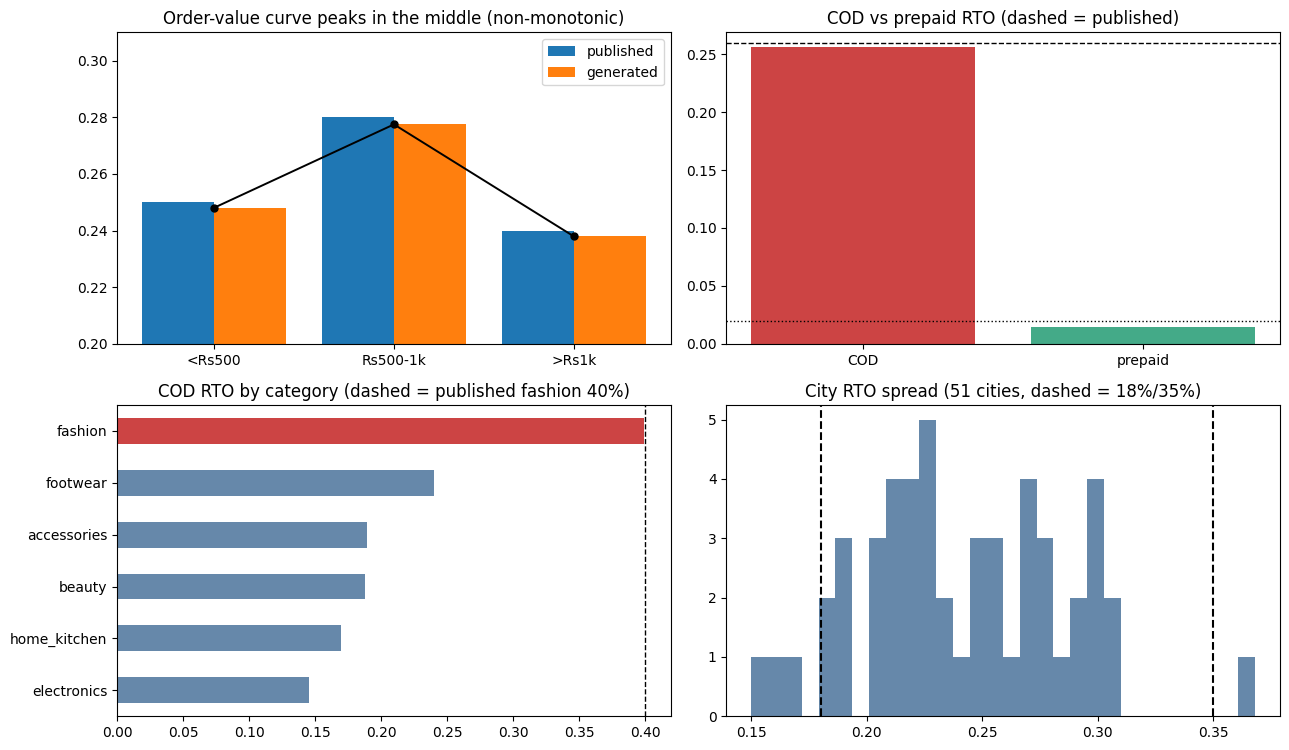

In [19]:
fig, ax = plt.subplots(2, 2, figsize=(13, 7.6))

pub = {"under_500": evidence["order_value_bands"]["under_500"]["value"],
       "500_1000": evidence["order_value_bands"]["mid_500_1000"]["value"],
       "1000_plus": evidence["order_value_bands"]["over_1000"]["value"]}
obs = [calibration["cod_rto_by_band"][b] for b in gen.VALUE_BANDS]
x = np.arange(3)
ax[0, 0].bar(x - 0.2, [pub[b] for b in gen.VALUE_BANDS], 0.4, label="published")
ax[0, 0].bar(x + 0.2, obs, 0.4, label="generated")
ax[0, 0].plot(x, obs, "o-", color="k", lw=1.4, ms=5)
ax[0, 0].set_xticks(x, ["<Rs500", "Rs500-1k", ">Rs1k"])
ax[0, 0].set_ylim(0.20, 0.31)
ax[0, 0].set_title("Order-value curve peaks in the middle (non-monotonic)")
ax[0, 0].legend()

ax[0, 1].bar(["COD", "prepaid"],
             [calibration["cod_rto_rate"], calibration["prepaid_rto_rate"]],
             color=["#c44", "#4a8"])
ax[0, 1].axhline(evidence["cod_rto_rate"]["value"], ls="--", c="k", lw=1)
ax[0, 1].axhline(evidence["prepaid_rto_rate"]["value"], ls=":", c="k", lw=1)
ax[0, 1].set_title("COD vs prepaid RTO (dashed = published)")

cat = pd.Series(calibration["cod_rto_by_category"]).sort_values()
cat.plot(kind="barh", ax=ax[1, 0],
         color=["#c44" if c == "fashion" else "#68a" for c in cat.index])
ax[1, 0].axvline(evidence["fashion_rto_rate"]["value"], ls="--", c="k", lw=1)
ax[1, 0].set_title("COD RTO by category (dashed = published fashion 40%)")

city_rates = (cod.groupby("city")["rto"].agg(["mean", "size"])
              .query("size >= 100")["mean"])
ax[1, 1].hist(city_rates, bins=30, color="#68a")
ax[1, 1].axvline(lo, ls="--", c="k"); ax[1, 1].axvline(hi, ls="--", c="k")
ax[1, 1].set_title(f"City RTO spread ({len(city_rates)} cities, dashed = 18%/35%)")
plt.tight_layout()
plt.savefig(ROOT / "reports/figures/01_calibration_check.png", dpi=140, bbox_inches="tight")
plt.show()

## 8. Chronological split 70/10/20

In [20]:
# Chronological, never random. A random split would let the model learn from
# orders placed after the ones it is scored on - the future leaking backwards.
splits = gen.chronological_split(orders)

summary = pd.DataFrame({
    name: {
        "orders": len(part),
        "first": part["order_ts"].min().strftime("%Y-%m-%d"),
        "last": part["order_ts"].max().strftime("%Y-%m-%d"),
        "rto_rate": round(part["rto"].mean(), 4),
        "cod_rto_rate": round(part.loc[part.is_cod, "rto"].mean(), 4),
        "cod_share": round(part["is_cod"].mean(), 4),
    }
    for name, part in splits.items()
}).T
display(summary)

assert splits["train"]["order_ts"].max() <= splits["val"]["order_ts"].min()
assert splits["val"]["order_ts"].max() <= splits["test"]["order_ts"].min()
print("OK: strictly chronological, no overlap.")

,orders,first,last,rto_rate,cod_rto_rate,cod_share
train,35000,2024-01-01,2025-01-22,0.1696,0.2658,0.6172
val,5000,2025-01-22,2025-03-16,0.155,0.2387,0.63
test,10000,2025-03-16,2025-06-30,0.1473,0.2309,0.6155


OK: strictly chronological, no overlap.


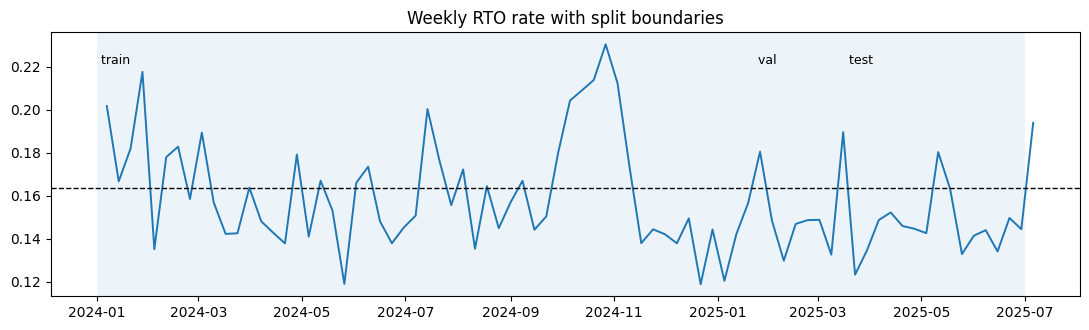

In [21]:
# Base rate drift across the split is a fact about the data, not a bug: festive
# windows sit inside the train period. 05 measures performance across the full
# 18-35% prevalence range precisely because this drift is real.
fig, ax = plt.subplots(figsize=(11, 3.4))
w = orders.set_index("order_ts")["rto"].resample("W").mean()
ax.plot(w.index, w.values, lw=1.4)
for name, part in splits.items():
    ax.axvspan(part["order_ts"].min(), part["order_ts"].max(), alpha=0.08)
    ax.text(part["order_ts"].min(), w.max() * 0.98, f" {name}", va="top", fontsize=9)
ax.axhline(orders["rto"].mean(), ls="--", c="k", lw=1)
ax.set_title("Weekly RTO rate with split boundaries")
plt.tight_layout()
plt.savefig(ROOT / "reports/figures/01_split_timeline.png", dpi=140, bbox_inches="tight")
plt.show()

## 9. Write data/raw + data/processed

In [22]:
# data/raw       - the order log a merchant would plausibly hold. Nothing
#                  post-outcome, nothing latent.
# data/interim   - generator latents, for auditing only. Using any of these as
#                  a feature is leakage by definition (guarded in tests).
# data/processed - raw + causal history + engineered features, split three ways.
#                  Target encoding is NOT applied here; it is fitted out-of-fold
#                  inside the modelling folds in notebook 03.

written = []

raw_path = ROOT / "data/raw/orders.csv"
orders[gen.RAW_COLUMNS].to_csv(raw_path, index=False)
written.append(raw_path)

lat_path = ROOT / "data/interim/latents.csv"
orders[gen.LATENT_COLUMNS].to_csv(lat_path, index=False)
written.append(lat_path)

for name, frame in [("customers", customers), ("pincode_footprint", footprint)]:
    p = ROOT / f"data/interim/{name}.csv"
    frame.to_csv(p, index=False)
    written.append(p)

print(f"raw order log columns ({len(gen.RAW_COLUMNS)}):")
print("  " + ", ".join(gen.RAW_COLUMNS))
print()
print("latents held back:", ", ".join(c for c in gen.LATENT_COLUMNS if c.startswith("_")))

raw order log columns (24):
  order_id, order_ts, customer_id, customer_name, phone, address_line, pincode, city, district, state, pincode_tier, category, order_value, order_value_band, discount_pct, payment_mode, is_cod, is_festive, is_alternate_address, delivery_days_est, signup_date, account_age_days, order_velocity_24h, rto

latents held back: _pincode_rto_prior, _reliability_z, _address_quality, _p_rto_true


In [23]:
keep = gen.RAW_COLUMNS + gen.HISTORY_COLUMNS

for name, part in splits.items():
    frame = add_engineered_features(part[keep].reset_index(drop=True))
    p = ROOT / f"data/processed/{name}.parquet"
    frame.to_parquet(p, index=False)
    written.append(p)
    print(f"{name:6s} {len(frame):>6,} rows x {frame.shape[1]:>3} cols -> {p.relative_to(ROOT)}")

display(frame.head(3))

train  35,000 rows x  42 cols -> data\processed\train.parquet
val     5,000 rows x  42 cols -> data\processed\val.parquet


test   10,000 rows x  42 cols -> data\processed\test.parquet


,order_id,order_ts,customer_id,customer_name,phone,address_line,pincode,city,district,state,...,addr_has_house_number,addr_has_landmark,addr_gibberish_score,addr_quality_score,tier_ordinal,log_order_value,discount_amount,log_account_age,is_first_order,pincode_prefix3
0,ORD040000,2025-03-16 23:59:56.400000000,CUST018010,Atharv Pant,5990303458,"H No 76/30, Hayre Circle, Warangal Layout, War...",506345,Warangal,Warangal,Andhra Pradesh,...,1,0,0.0,0.650,1,6.638568,67.91,6.345636,0,506
1,ORD040001,2025-03-17 06:08:49.477041571,CUST014559,Kavya Rout,6041992623,"H No 37, Kale Marg, Near Water Tank, Lucknow W...",227131,Lucknow,Lucknow,Uttar Pradesh,...,1,1,0.0,0.975,1,6.278521,69.69,5.125510,0,227
2,ORD040002,2025-03-17 08:14:12.766352160,CUST018998,Nimrat Lanka,9137618319,"H No 499, Dewan Marg, Near City Hospital, Chur...",331032,Churu,Churu,Rajasthan,...,1,1,0.0,0.975,2,7.013915,119.99,6.267846,0,331


In [24]:
cal_path = ROOT / "reports/results/01_calibration.json"
with open(cal_path, "w", encoding="utf-8") as fh:
    json.dump({
        "calibration": calibration,
        "solved_offsets": diagnostics["offsets"],
        "targets": diagnostics["targets"],
        "expected_cod_rate": diagnostics["expected_cod_rate"],
        "expected_prepaid_rate": diagnostics["expected_prepaid_rate"],
        "bayes_ceiling": {
            "roc_auc": float(roc_auc_score(orders["rto"], orders["_p_rto_true"])),
            "pr_auc": float(average_precision_score(orders["rto"], orders["_p_rto_true"])),
            "brier": float(brier_score_loss(orders["rto"], orders["_p_rto_true"])),
        },
        "split_summary": summary.to_dict(orient="index"),
    }, fh, indent=2)
written.append(cal_path)
print(f"wrote {cal_path.relative_to(ROOT)}")

wrote reports\results\01_calibration.json


## 10. SHA-256 manifest

In [25]:
manifest = gen.write_manifest(
    written,
    ROOT / "reports/results/01_manifest.json",
    root=ROOT,
    extra={
        "n_orders": int(len(orders)),
        "n_customers": int(len(customers)),
        "window": [str(gen.WINDOW_START.date()), str(gen.WINDOW_END.date())],
        "split": {"train": gen.TRAIN_FRAC, "val": gen.VAL_FRAC, "test": gen.TEST_FRAC},
    },
)
display(pd.DataFrame(manifest["files"]).T[["sha256", "bytes"]])

,sha256,bytes
data/interim/customers.csv,fc8df89dfd1eface0990e120c0b8e03392d800db5fae4a...,4444163
data/interim/latents.csv,b4a0c006faf2bd9f62388777f645d52faf0f3e3df5bff7...,4441644
data/interim/pincode_footprint.csv,5127c45fa0f5cdf1206fc2a05c2590b193d7d1a6c6fe57...,323124
data/processed/test.parquet,6c0d329d621f93596becd55aec92dfcbc190ebdcd5aa36...,1012098
data/processed/train.parquet,d9c211a4858d339173f5659427bb3457d1a617036df54f...,2731876
data/processed/val.parquet,8773767e69b153f762e20bc1e22ef26e386200b27a1506...,563869
data/raw/orders.csv,089a9d5e61441d4ce90251c227a4677b142a0dde94535b...,12529383
reports/results/01_calibration.json,3d3fe6dff7179b95882382e9de5f0ced87b1311dd1f0b5...,2580


In [26]:
# Reproducibility proof: regenerate the whole dataset from scratch through the
# packaged pipeline and require an identical label vector. This is the claim
# "two runs identical", checked rather than asserted in prose.
rerun = gen.build_dataset(
    evidence_path=ROOT / "config/evidence.yaml",
    pincode_path=ROOT / "data/external/india_pincodes.csv",
)["orders"]

pd.testing.assert_frame_equal(
    orders.reset_index(drop=True), rerun.reset_index(drop=True)
)
print("REPRODUCIBLE: independent regeneration is identical, all",
      f"{len(orders):,} rows and {orders.shape[1]} columns.")

REPRODUCIBLE: independent regeneration is identical, all 50,000 rows and 32 columns.


---

## Summary

| | |
|---|---|
| Orders | 50,000 on 3,500 real serviced pincodes |
| Customers | 20,000, persistent across orders |
| Split | chronological 70 / 10 / 20 |
| Calibration | asserted against `config/evidence.yaml`, mirrored in `tests/test_calibration.py` |
| Manifest | `reports/results/01_manifest.json` |

**Next:** `02_eda.ipynb` - train split only. The test set is not opened until `05`.